In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("EDA libraries imported successfully!")

EDA libraries imported successfully!


In [3]:
import sys
print(sys.executable)

c:\Program Files\Python311\python.exe


In [4]:
import sys

!{sys.executable} -m pip install seaborn

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import pandas as pd
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 20)


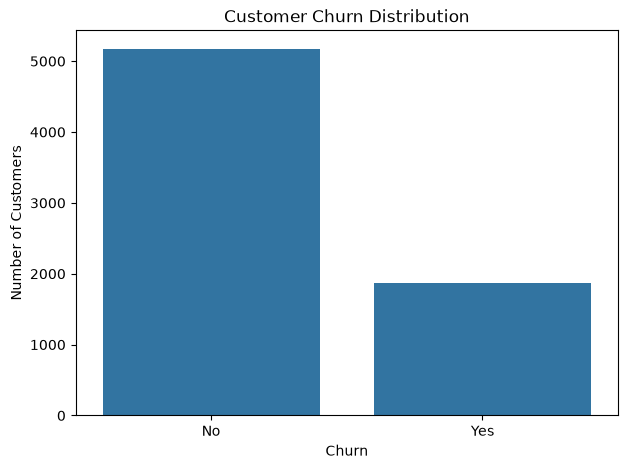

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
churn_counts = df["Churn"].value_counts()

print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


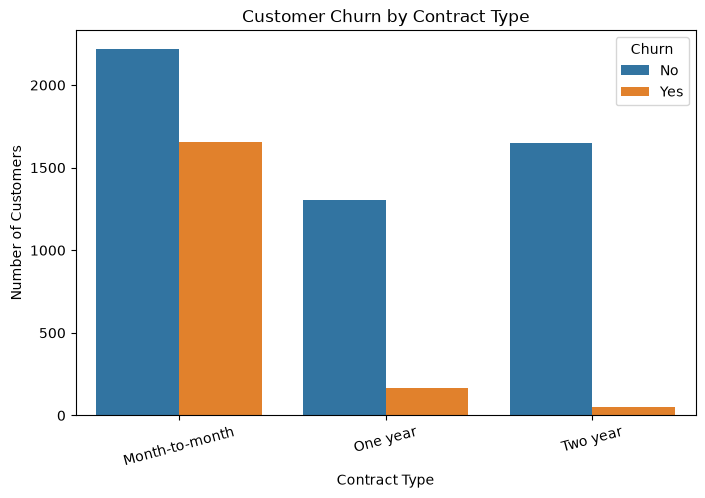

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [10]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


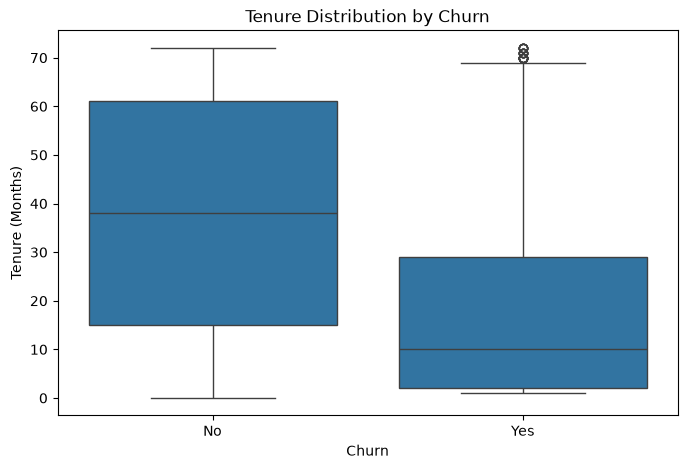

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

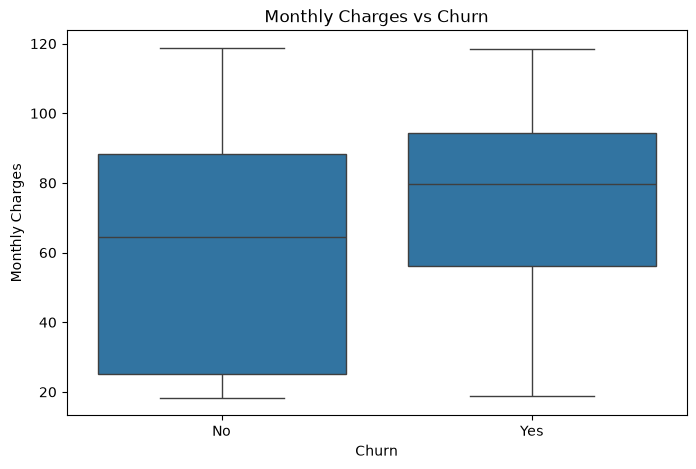

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

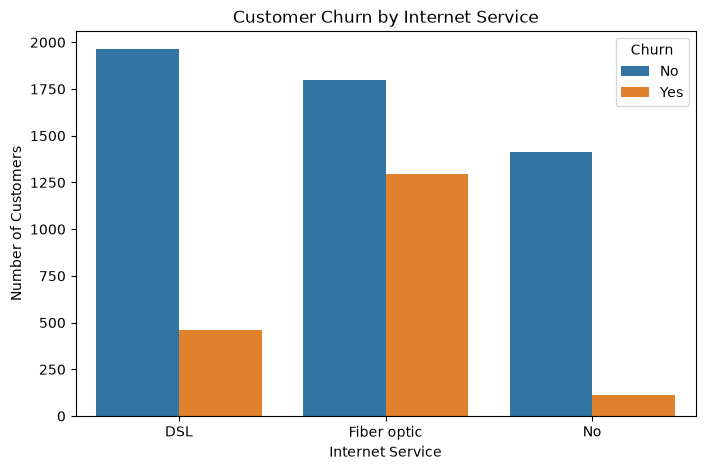

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

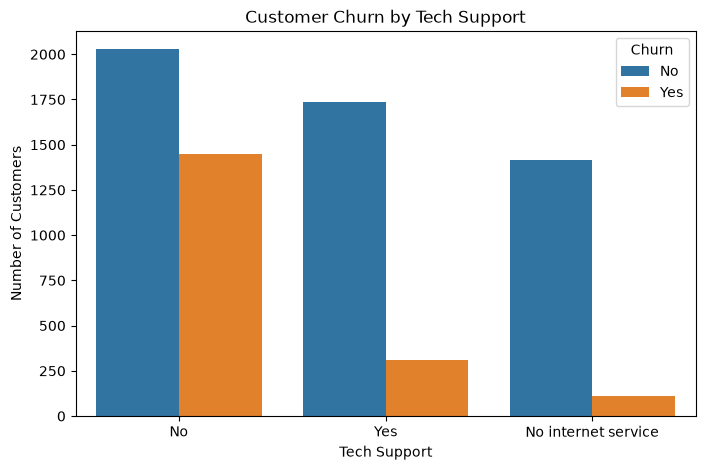

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

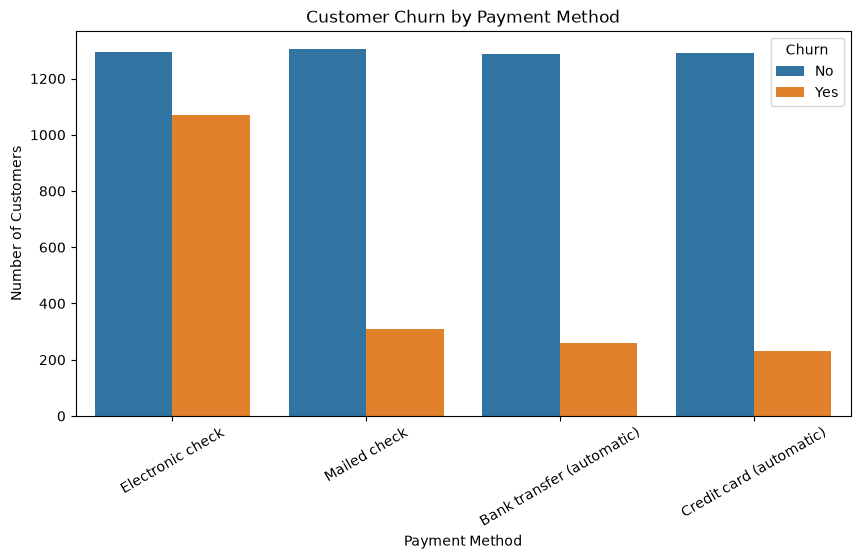

In [15]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

In [16]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [17]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [18]:
support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

print(support_churn.round(2))

Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


In [19]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn.round(2))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


In [20]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print(df[numeric_features].describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


In [21]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(senior_churn.round(2))

Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


In [22]:
eda_findings = pd.DataFrame({
    "Feature": [
        "Contract",
        "Internet Service",
        "Tech Support"
    ],
    "Key Observation": [
        "Month-to-month customers show substantially higher churn",
        "Fiber optic customers show substantially higher churn",
        "Customers without tech support show higher churn"
    ]
})

eda_findings

,Feature,Key Observation
0,Contract,Month-to-month customers show substantially hi...
1,Internet Service,Fiber optic customers show substantially highe...
2,Tech Support,Customers without tech support show higher churn


## EDA Conclusions

The exploratory analysis revealed several important patterns:

1. Month-to-month contract customers have substantially higher churn rates than customers with one-year or two-year contracts.

2. Fiber optic internet customers show a higher observed churn rate than DSL and customers without internet service.

3. Customers without technical support show a higher churn rate than customers who have technical support.

4. Churned customers generally show lower tenure and higher monthly charges compared with customers who stayed.

5. The target variable is imbalanced, so model evaluation should not rely only on accuracy.

These observations will guide the feature engineering and machine learning stages.

In [23]:
df_model=df.copy()
print("Model copied successfully!")
print(df_model.shape)

Model copied successfully!
(7043, 20)


In [24]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df_model["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [26]:
print(df_model.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [27]:
print(df_model.shape)

(7043, 20)


In [28]:
categorical_cols = df_model.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\hp\AppData\Local\Temp\ipykernel_20212\1977960394.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include=["object"]).columns


In [29]:
numeric_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

print("Numeric columns:")
print(numeric_cols.tolist())

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [30]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [31]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Encoded X shape:", X_encoded.shape)
print(X_encoded.head())

Encoded X shape: (7043, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                

In [32]:
print("Missing values:")
print(X_encoded.isnull().sum().sum())

Missing values:
0


In [33]:
print("Target distribution:")
print(y.value_counts())

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
